[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%202/3PM_Compressed_Sensing.ipynb)

# Compressed sensing: learn more from fewer measurements

We normally measure every pixel. Compressed sensing asks a more useful question:

> If an image has structure, can we measure only part of it and still recover the whole?

In this notebook you will:

- choose how measurement locations are sampled,
- compare three reconstruction methods,
- see why the choice of loss function matters,
- change a few parameters and observe the trade-offs, and



## 1. Google Colab setup

In Colab, run the next cell to clone the workshop repository 

In [ ]:
!git clone https://github.com/gduscher/MLSTEM2026.git
!pip install ipympl

Now go to Runtime > Restart Session before continuing

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage
from scipy.fft import dctn, idctn

import google
google.colab.output.enable_custom_widget_manager()

## 2. The idea in one equation

Let $x$ be the complete image and $M$ be a mask containing ones where we measure and zeros where we do not. Our measurements are

$$y = M \odot x.$$

There are many possible images that agree with a small set of measurements. Reconstruction becomes possible when we add a belief about ordinary images: they are usually **simple in the right representation**. For example, they may use only a modest number of cosine patterns or have mostly smooth regions separated by edges.

A common reconstruction recipe is

$$\hat{x} = \arg\min_z \; \mathcal{L}(M \odot z, y) + \lambda R(z).$$

The loss $\mathcal{L}$ asks, ‘Does the reconstruction agree with what we measured?’ The regularizer $R$ asks, ‘Does it look like the kind of signal we expect?’ The parameter $\lambda$ balances those two wishes.

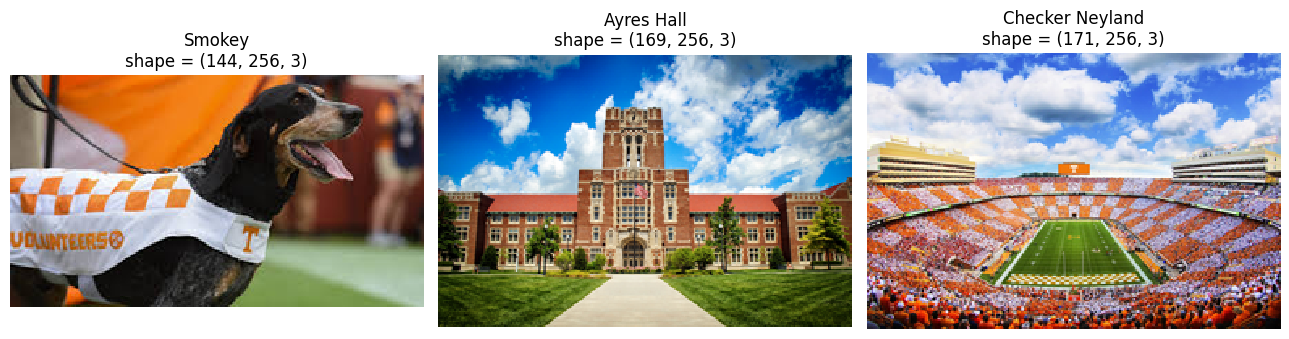

In [2]:
# Load in the images
image_dir = './MLSTEM2026/Day 2/compressed_sensing/'

image_files = {
    'Smokey': image_dir + 'smokey.jpeg',
    'Ayres Hall': image_dir + 'ayreshall.jpeg',
    'Checker Neyland': image_dir + 'checkerneyland.jpeg',
}

def load_image(path, max_side=256):
    with Image.open(path) as source:
        image = source.convert('RGB')
        image.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
        return np.asarray(image, dtype=np.float32) / 255.0

images = {name: load_image(path) for name, path in image_files.items()}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, image) in zip(axes, images.items()):
    ax.imshow(image)
    ax.set_title(f'{name}\nshape = {image.shape}')
    ax.axis('off')
plt.tight_layout()

## 3. Control panel

Change the values in the next cell, then rerun from here downward. 

In [ ]:
image_name = 'Checker Neyland'
sample_fraction = 0.10
sampling_method = 'random'
reconstruction_method = 'dct'
data_loss = 'l2'
iterations = 40
sparsity_fraction = 0.08
tv_step = 0.08
huber_delta = 0.05
random_seed = 7

image = images[image_name]
print(f'Using {100 * sample_fraction:.0f}% of the pixel locations in {image_name}.')

Using 10% of the pixel locations in Checker Neyland.


## 4. Choose where to measure

- **Random** sampling spreads measurements irregularly. This tends to avoid repeating blind spots and is the classic compressed-sensing choice.
- A **grid** is simple and easy for hardware, but regular gaps can line up with regular image features.


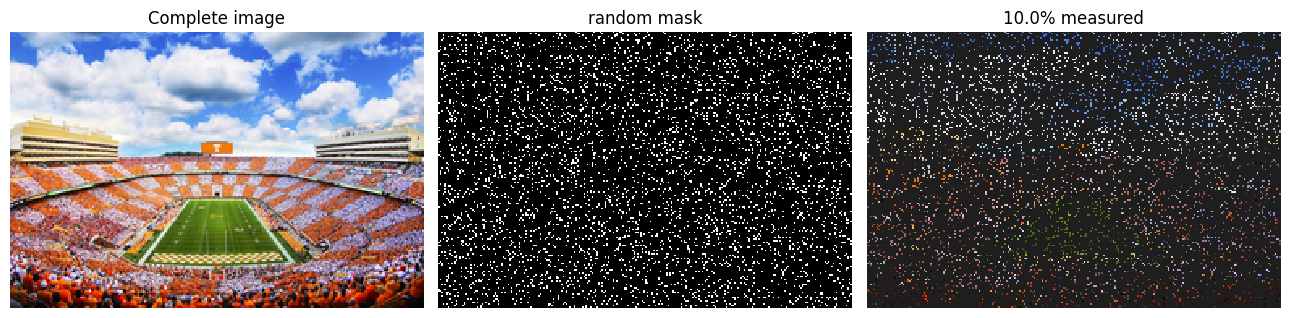

In [4]:
def make_sampling_mask(image, fraction, method='random', seed=0):
    height, width = image.shape[:2]
    pixel_count = height * width
    sample_count = max(1, int(round(fraction * pixel_count)))
    rng = np.random.default_rng(seed)
    mask = np.zeros(pixel_count, dtype=bool)

    if method == 'random':
        chosen = rng.choice(pixel_count, sample_count, replace=False)
        mask[chosen] = True
    elif method == 'grid':
        row_count = max(1, int(round(np.sqrt(sample_count * height / width))))
        column_count = max(1, int(round(sample_count / row_count)))
        rows = np.linspace(0, height - 1, row_count, dtype=int)
        columns = np.linspace(0, width - 1, column_count, dtype=int)
        mask.reshape(height, width)[np.ix_(rows, columns)] = True
    else:
        raise ValueError(f'Unknown sampling method: {method}')

    return mask.reshape(height, width)


mask = make_sampling_mask(image, sample_fraction, sampling_method, random_seed)
sampled = image * mask[..., None]
display_sampled = np.where(mask[..., None], image, 0.12)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image)
axes[0].set_title('Complete image')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'{sampling_method} mask')
axes[2].imshow(display_sampled)
axes[2].set_title(f'{mask.mean():.1%} measured')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## 5. Reconstruct what was not measured

We compare three methods:

1. **Nearest neighbor** copies the closest measurement into every gap. It is fast and a useful baseline, but it does not use compressed-sensing mathematics.
2. **DCT sparsity** assumes an image can be described with relatively few two-dimensional cosine patterns. Each iteration keeps the strongest DCT coefficients, returns to image space, and checks the answer against the measurements. In shorthand, its regularizer is $R(z) = \|\operatorname{DCT}(z)\|_0$, the number of retained coefficients.
3. **Total variation (TV)** prefers neighboring pixels to be similar while allowing some sharp edges. Its regularizer is approximately $R(z) = \sum \sqrt{(\nabla_x z)^2 + (\nabla_y z)^2}$. It often creates smooth, cartoon-like regions.

These compact implementations favor clarity over research-grade speed.

In [5]:
def to_image_planes(array, sample_axes=(0, 1)):
    moved = np.moveaxis(np.asarray(array), sample_axes, (-2, -1))
    moved_shape = moved.shape
    planes = moved.reshape(-1, moved_shape[-2], moved_shape[-1])
    return planes, moved_shape


def from_image_planes(planes, moved_shape, sample_axes=(0, 1)):
    moved = planes.reshape(moved_shape)
    return np.moveaxis(moved, (-2, -1), sample_axes)


def loss_update(residual, loss='l2', delta=0.05):
    if loss == 'l2':
        return residual
    if loss == 'l1':
        return delta * np.sign(residual)
    if loss == 'huber':
        return np.clip(residual, -delta, delta)
    raise ValueError(f'Unknown loss: {loss}')

In [6]:
def nearest_reconstruct(sampled, mask, sample_axes=(0, 1)):
    planes, moved_shape = to_image_planes(sampled, sample_axes)
    _, nearest_indices = ndimage.distance_transform_edt(~mask, return_indices=True)
    filled = planes[:, nearest_indices[0], nearest_indices[1]]
    return from_image_planes(filled, moved_shape, sample_axes)


def dct_reconstruct(
    sampled,
    mask,
    iterations=40,
    sparsity_fraction=0.08,
    loss='l2',
    delta=0.05,
    sample_axes=(0, 1),
):
    observed, moved_shape = to_image_planes(sampled, sample_axes)
    estimate, _ = to_image_planes(nearest_reconstruct(sampled, mask, sample_axes), sample_axes)
    coefficient_count = mask.size
    keep_count = max(1, int(round(sparsity_fraction * coefficient_count)))

    for _ in range(iterations):
        coefficients = dctn(estimate, axes=(-2, -1), norm='ortho')
        magnitudes = np.abs(coefficients).reshape(len(coefficients), -1)
        threshold = np.partition(magnitudes, -keep_count, axis=1)[:, -keep_count]
        keep = np.abs(coefficients) >= threshold[:, None, None]
        proposal = idctn(coefficients * keep, axes=(-2, -1), norm='ortho')
        residual = observed[:, mask] - proposal[:, mask]
        proposal[:, mask] += loss_update(residual, loss, delta)
        estimate = np.clip(proposal, 0.0, 1.0)

    return from_image_planes(estimate, moved_shape, sample_axes)


def tv_reconstruct(
    sampled,
    mask,
    iterations=40,
    step=0.08,
    loss='l2',
    delta=0.05,
    sample_axes=(0, 1),
):
    observed, moved_shape = to_image_planes(sampled, sample_axes)
    estimate, _ = to_image_planes(nearest_reconstruct(sampled, mask, sample_axes), sample_axes)

    for _ in range(iterations):
        gradient_x = np.diff(estimate, axis=-1, append=estimate[..., -1:])
        gradient_y = np.diff(estimate, axis=-2, append=estimate[..., -1:, :])
        magnitude = np.sqrt(gradient_x ** 2 + gradient_y ** 2 + 1e-6)
        direction_x = gradient_x / magnitude
        direction_y = gradient_y / magnitude
        divergence = direction_x.copy()
        divergence[..., 1:] -= direction_x[..., :-1]
        divergence += direction_y
        divergence[..., 1:, :] -= direction_y[..., :-1, :]
        proposal = np.clip(estimate + step * divergence, 0.0, 1.0)
        residual = observed[:, mask] - proposal[:, mask]
        proposal[:, mask] += loss_update(residual, loss, delta)
        estimate = np.clip(proposal, 0.0, 1.0)

    return from_image_planes(estimate, moved_shape, sample_axes)


def reconstruct(sampled, mask, method='dct', loss='l2', sample_axes=(0, 1)):
    if method == 'nearest':
        return nearest_reconstruct(sampled, mask, sample_axes)
    if method == 'dct':
        return dct_reconstruct(
            sampled, mask, iterations, sparsity_fraction, loss, huber_delta, sample_axes
        )
    if method == 'tv':
        return tv_reconstruct(
            sampled, mask, iterations, tv_step, loss, huber_delta, sample_axes
        )
    raise ValueError(f'Unknown reconstruction method: {method}')

### Measure reconstruction quality

Because this is a teaching example, we know the complete image and can score the reconstruction. **MAE** is the average absolute pixel error. **PSNR** is a logarithmic signal-to-error score; higher is better. Real sparse experiments usually require validation measurements, simulations, or task-specific checks because the unmeasured truth is unavailable.

MAE: 0.1009 | PSNR: 16.29 dB


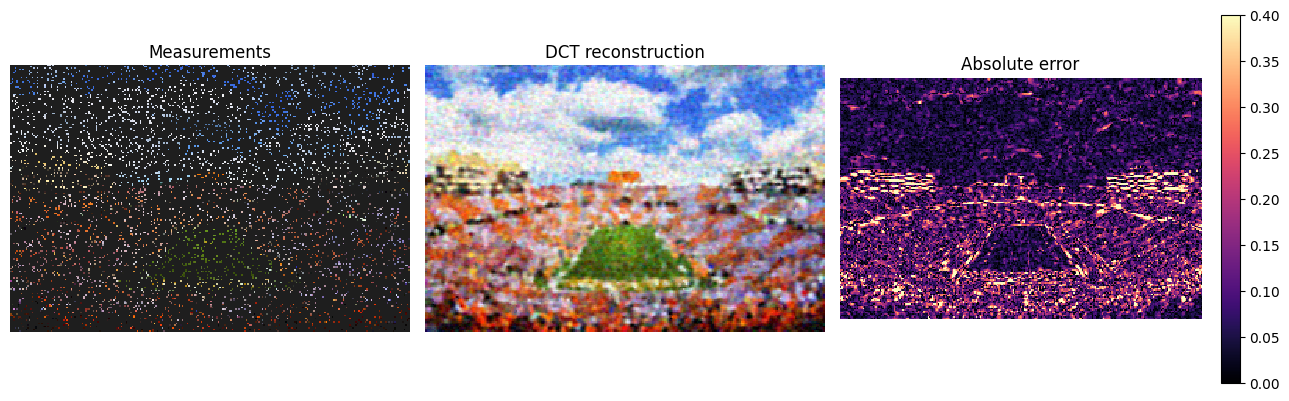

In [7]:
def quality_metrics(reference, estimate):
    error = reference - estimate
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    psnr = float('inf') if mse == 0 else float(10 * np.log10(1.0 / mse))
    return {'MAE': mae, 'PSNR': psnr}


reconstruction = reconstruct(sampled, mask, reconstruction_method, data_loss)
metrics = quality_metrics(image, reconstruction)
error_map = np.mean(np.abs(image - reconstruction), axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_sampled)
axes[0].set_title('Measurements')
axes[1].imshow(reconstruction)
axes[1].set_title(f'{reconstruction_method.upper()} reconstruction')
error_plot = axes[2].imshow(error_map, cmap='magma', vmin=0, vmax=0.4)
axes[2].set_title('Absolute error')
for ax in axes:
    ax.axis('off')
fig.colorbar(error_plot, ax=axes[2], fraction=0.046)
plt.tight_layout()
mae = metrics['MAE']
psnr = metrics['PSNR']
print(f'MAE: {mae:.4f} | PSNR: {psnr:.2f} dB')

## 6. Compare reconstruction methods fairly

The next cell gives all three methods exactly the same measurements. Look beyond the score: where does each method fail, and which failure would matter for your scientific task?

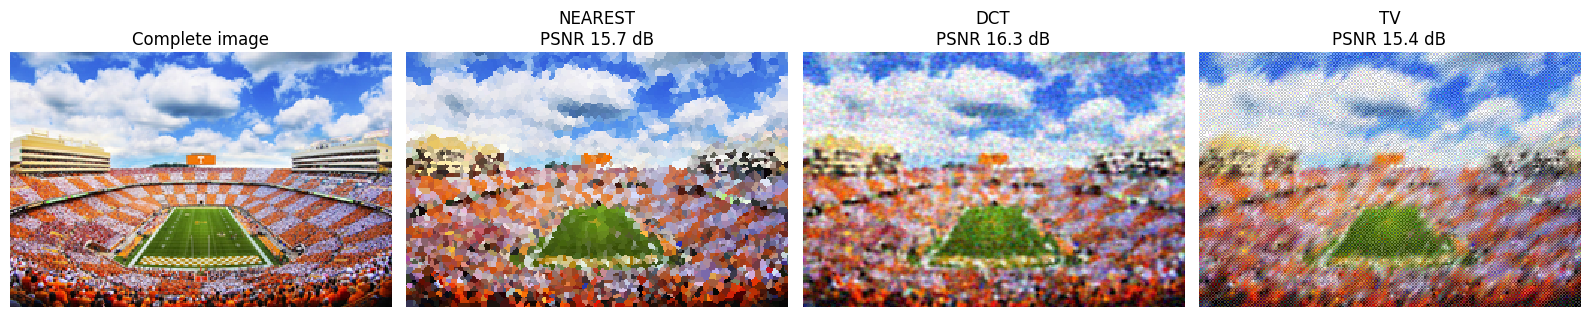

In [8]:
method_names = ['nearest', 'dct', 'tv']
method_results = {
    name: reconstruct(sampled, mask, name, data_loss)
    for name in method_names
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title('Complete image')
for ax, name in zip(axes[1:], method_names):
    result_metrics = quality_metrics(image, method_results[name])
    score = result_metrics['PSNR']
    ax.imshow(method_results[name])
    ax.set_title(f'{name.upper()}\nPSNR {score:.1f} dB')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## 7. Loss functions: what counts as a bad disagreement?

For a residual $r = y - M \odot z$:

- **L2:** $\mathcal{L}(r) = r^2$. Large errors receive a very large penalty. This is a natural choice for Gaussian noise, but a few broken measurements can dominate it.
- **L1:** $\mathcal{L}(r) = |r|$. Every error has steadier influence, making the fit more resistant to outliers.
- **Huber:** quadratic for small errors and linear for large errors. It is a compromise between L2 smoothness and L1 robustness. `huber_delta` sets where the transition happens.

The next experiment deliberately corrupts a small fraction of measured values so the difference becomes visible.

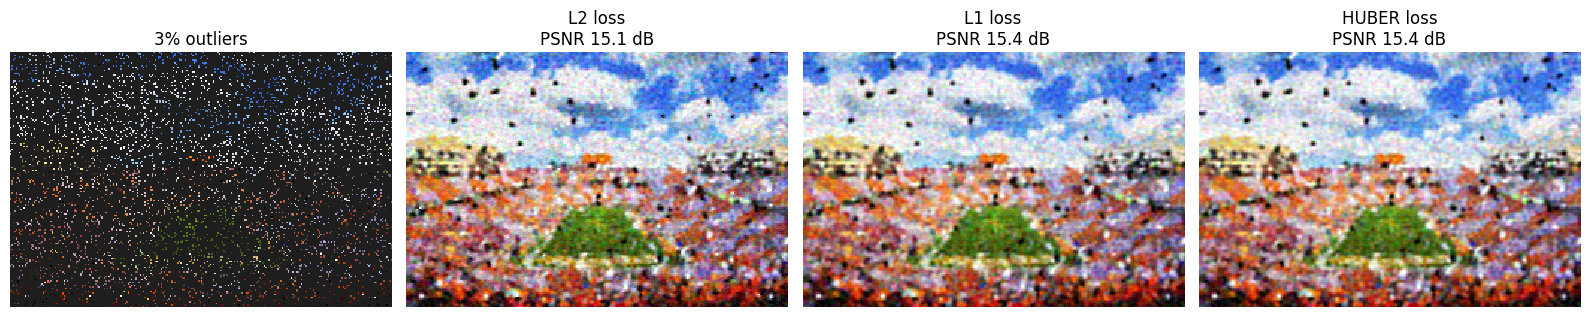

In [9]:
rng = np.random.default_rng(random_seed)
corrupted_sampled = sampled.copy()
measured_rows, measured_columns = np.nonzero(mask)
outlier_count = max(1, int(0.03 * len(measured_rows)))
outlier_indices = rng.choice(len(measured_rows), outlier_count, replace=False)
outlier_rows = measured_rows[outlier_indices]
outlier_columns = measured_columns[outlier_indices]
corrupted_sampled[outlier_rows, outlier_columns] = rng.integers(0, 2, size=(outlier_count, 1))

loss_names = ['l2', 'l1', 'huber']
loss_results = {
    name: dct_reconstruct(
        corrupted_sampled, mask, iterations, sparsity_fraction, name, huber_delta
    )
    for name in loss_names
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(np.where(mask[..., None], corrupted_sampled, 0.12))
axes[0].set_title('3% outliers')
for ax, name in zip(axes[1:], loss_names):
    result_metrics = quality_metrics(image, loss_results[name])
    score = result_metrics['PSNR']
    ax.imshow(loss_results[name])
    ax.set_title(f'{name.upper()} loss\nPSNR {score:.1f} dB')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## 9. Let uncertainty choose the next measurement

In a real experiment, the complete map is unknown. We therefore cannot compare a reconstruction with ground truth after every step. Instead, we can make several plausible reconstructions and ask where they disagree.

The acquisition score below combines two ideas:

- **Model disagreement:** DCT reconstructions with different sparsity settings give different answers where the data do not constrain them well.
- **Distance from evidence:** a location far from every measurement receives an exploration bonus, even if the models accidentally agree.

This score is a useful guide for where to measure next, but it is not a calibrated probability or confidence interval.

### Copy cell 1 for notebook 09

The next code cell is self-contained. Copy the **entire cell** into the first empty cell under **Task 2** in `09_Hackathon_Digital_Twin.ipynb`.

In [10]:
import numpy as np
from scipy import ndimage
from scipy.fft import dctn, idctn


def nearest_scalar_fill(values, measured_mask):
    if not np.any(measured_mask):
        raise ValueError('At least one measurement is required.')

    _, nearest_indices = ndimage.distance_transform_edt(
        ~measured_mask, return_indices=True
    )
    return values[nearest_indices[0], nearest_indices[1]]


def dct_scalar_reconstruct(
    normalized_values, measured_mask, iterations=30, sparsity_fraction=0.08
):
    estimate = nearest_scalar_fill(normalized_values, measured_mask)
    keep_count = max(1, int(round(sparsity_fraction * estimate.size)))

    for _ in range(iterations):
        coefficients = dctn(estimate, norm='ortho')
        threshold = np.partition(np.abs(coefficients).ravel(), -keep_count)[-keep_count]
        proposal = idctn(
            coefficients * (np.abs(coefficients) >= threshold), norm='ortho'
        )
        proposal[measured_mask] = normalized_values[measured_mask]
        estimate = np.clip(proposal, 0.0, 1.0)

    return estimate


def reconstruct_scalar_map(
    measured_values, measured_mask, region_mask, value_bounds, iterations=30
):
    lower, upper = value_bounds
    value_span = upper - lower
    if value_span <= 0:
        raise ValueError('value_bounds must increase from lower to upper.')

    normalized_values = np.zeros_like(measured_values, dtype=float)
    normalized_values[measured_mask] = np.clip(
        (measured_values[measured_mask] - lower) / value_span, 0.0, 1.0
    )

    sparsity_choices = [0.04, 0.08, 0.16]
    candidates = [
        dct_scalar_reconstruct(
            normalized_values, measured_mask, iterations, sparsity
        )
        for sparsity in sparsity_choices
    ]
    candidates = np.asarray(candidates)
    reconstruction_normalized = candidates.mean(axis=0)

    disagreement = candidates.std(axis=0)
    disagreement /= max(float(disagreement[region_mask].max()), 1e-12)

    distance = ndimage.distance_transform_edt(~measured_mask)
    distance /= max(float(distance[region_mask].max()), 1e-12)

    uncertainty = 0.7 * disagreement + 0.3 * distance
    uncertainty[~region_mask] = np.nan
    uncertainty[measured_mask] = 0.0

    reconstruction = lower + value_span * reconstruction_normalized
    reconstruction[~region_mask] = np.nan
    return reconstruction, uncertainty

### Take one measurement, update, and repeat

Here the grayscale photograph is hidden behind `simulated_measure`. The reconstruction code can request one value at a chosen location, just as the microscope loop will request one diffraction pattern and reduce it to one lattice parameter. The hidden map is shown only after the loop so we can evaluate the lesson.

Next measurement at row 56, column 52: 0.782


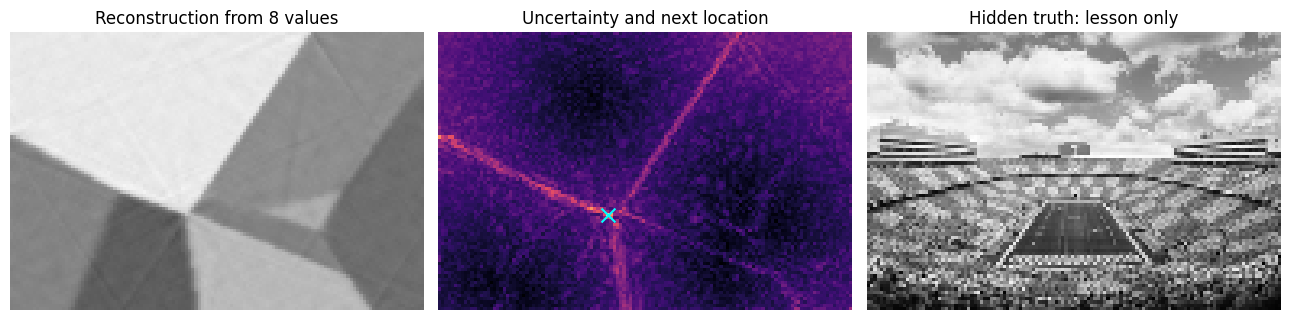

In [11]:
hidden_scalar_map = image[::2, ::2].mean(axis=-1)
region_mask = np.ones_like(hidden_scalar_map, dtype=bool)
measured_values = np.zeros_like(hidden_scalar_map)
measured_mask = np.zeros_like(hidden_scalar_map, dtype=bool)
rng = np.random.default_rng(random_seed)


def simulated_measure(row, column):
    return float(hidden_scalar_map[row, column])


initial_count = 8
initial_indices = rng.choice(hidden_scalar_map.size, initial_count, replace=False)
for index in initial_indices:
    row, column = np.unravel_index(index, hidden_scalar_map.shape)
    measured_values[row, column] = simulated_measure(row, column)
    measured_mask[row, column] = True

reconstruction, uncertainty = reconstruct_scalar_map(
    measured_values, measured_mask, region_mask, value_bounds=(0.0, 1.0)
)
next_row, next_column = np.unravel_index(
    np.nanargmax(uncertainty), uncertainty.shape
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(reconstruction, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Reconstruction from {measured_mask.sum()} values')
axes[1].imshow(uncertainty, cmap='magma', vmin=0, vmax=1)
axes[1].scatter(next_column, next_row, marker='x', s=100, color='cyan')
axes[1].set_title('Uncertainty and next location')
axes[2].imshow(hidden_scalar_map, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Hidden truth: lesson only')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

next_value = simulated_measure(next_row, next_column)
measured_values[next_row, next_column] = next_value
measured_mask[next_row, next_column] = True
print(f'Next measurement at row {next_row}, column {next_column}: {next_value:.3f}')

The next cell continues the same acquire–reconstruct–choose loop. Notice that the algorithm never reads `hidden_scalar_map` directly; only `simulated_measure` does.

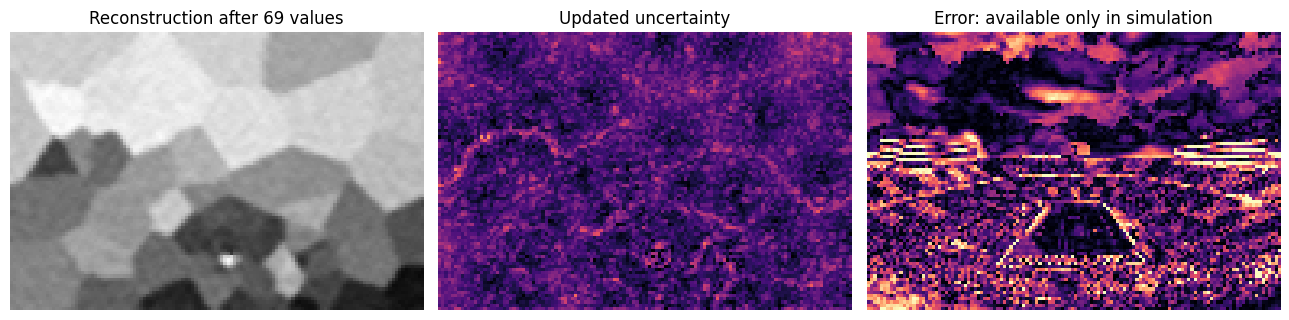

In [14]:
additional_measurements = 20

for iteration in range(additional_measurements):
    reconstruction, uncertainty = reconstruct_scalar_map(
        measured_values, measured_mask, region_mask, value_bounds=(0.0, 1.0)
    )
    next_row, next_column = np.unravel_index(
        np.nanargmax(uncertainty), uncertainty.shape
    )
    measured_values[next_row, next_column] = simulated_measure(next_row, next_column)
    measured_mask[next_row, next_column] = True

reconstruction, uncertainty = reconstruct_scalar_map(
    measured_values, measured_mask, region_mask, value_bounds=(0.0, 1.0)
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(reconstruction, cmap='gray', vmin=0, vmax=1)

axes[0].set_title(f'Reconstruction after {measured_mask.sum()} values')
axes[1].imshow(uncertainty, cmap='magma', vmin=0, vmax=1)
axes[1].set_title('Updated uncertainty')
error = np.abs(hidden_scalar_map - reconstruction)
axes[2].imshow(error, cmap='magma', vmin=0, vmax=0.5)
axes[2].set_title('Error: available only in simulation')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## Continue with the digital twin
